In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymuhrec.utils.readers as rd

import pymuhrec.utils.readers as io
import pymuhrec.utils.imageutils as amg

import pymuhrec as pm
import gc
%config InlineBackend.figure_format = 'retina'

Define paths

In [3]:
datapath_projections = 'C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/02_rawdata/ct_3x1126_60s/'
datapath_ob_dc = 'C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/02_rawdata/OB2_DC2/'
datapath_save = 'C:/Users/msaca/Documents/muhrec2/imagingsuite/user/saved_data/'

Load in the OBs and DCs. Approximately 5gb of memory is needed during the loading for 240x2048x2048. Only one slide is kept in memory.

In [3]:
ob_uncropped = io.read_images(datapath_ob_dc+'OB2_DC2_{0:05d}.fits',3,242,averageStack=True).mean(axis=0)
dc_uncropped = io.read_images(datapath_ob_dc+'OB2_DC2_{0:05d}.fits',243,242+240,averageStack=True).mean(axis=0)

  0%|          | 0/240 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

We now process the projections. There are too many for loading all in at one, but we can do 6 batches to stay below 32GB

In [4]:
batch_number = 1
batch_sizes = np.array([600,600,600,600,600,3*126])
batch_index_last = np.cumsum(batch_sizes)
batch_index_first = np.append(0,batch_index_last[0:-1])+1

In [5]:
#proj = [] # Clear memory
#proj = io.read_images(datapath_projections+'ct_3x1126_60s_{0:05d}.fits',batch_index_first[batch_number],batch_index_last[batch_number]) # This takes a while

With the raw projections loaded, we want to do certain combinations of operations on them.
A: Treating same angles, B: lognormalizing C: spotcleaning.
We already have a procedure for doing lognormalization with dose correction, so no parameter tuning is necessary here. We have found good parameters for MorphSpotClean, although more parameter tuning is necessary in the future. We keep the parameters the same here. We have 3 ways of treating same angles: 1: Keep projections separate. 2: Take median. 3: Take mean. This leads to 9 different datasets:

```python
        1           2           3
ABC     A1BC      A2BC         A3BC
BAC     BA1C      BA2C         BA3C
BCA     BCA1      BCA2         BCA3

```python
We save data in the following order:
for i=order_of_module
    for j=batches
        Crop data to ROI (including whole disc)
        Process data by applying permute(A,B,C). After A, apply both none, mean, median
        Save data to disc
        Clear memory
    


Here is a small example to check the code, using order=ABC

In [6]:
#batch_sizes_example = batch_sizes #np.array([12,12,12,12,12,6])
#batch_index_first_example = batch_index_first
#print(batch_index_first_example)
#batch_index_last_example = batch_index_first_example+batch_sizes_example-1

batch_sizes = np.array([600,600,600,600,600,3*126])
batch_index_last = np.cumsum(batch_sizes)
batch_index_first = np.append(0,batch_index_last[0:-1])+1

ROI =  [190, 140, 1888, 1818] # ROI in the format [x0,y0,x1,y1] ([200, 200, 848, 848])
N_pixels_x = ROI[2] - ROI[0]
N_pixels_y = ROI[3] - ROI[1]

doseROI_original = [500,1450,560,1500] # The dose roi on the original dimensions before cropping
doseROI = [doseROI_original[0] - ROI[0], doseROI_original[1] - ROI[1], doseROI_original[2] - ROI[0], doseROI_original[3] - ROI[1]] # [600,600,620,620] #
ob = ob_uncropped[ROI[1]:ROI[3], ROI[0]:ROI[2]].copy()
dc = dc_uncropped[ROI[1]:ROI[3], ROI[0]:ROI[2]].copy()

norm = pm.NormalizeImage(True) # True for use logarithm
norm.setDoseROI(doseROI)
norm.setReferences(ob,dc)

msc = pm.MorphSpotClean()
msc.setThresholdByFraction(True)
msc.setLimits(applyClamp=True,vmin=-12.0,vmax=12.0,maxarea=30)
msc.setCleanMethod(pm.MorphDetectAllSpots, pm.MorphCleanReplace)
msc.useThreading(True)
msc.setEdgeConditioning(5)


In [7]:
for i_batch_number in range(len(batch_sizes)):
    proj = [] # Clear memory
    # A1
    proj = io.read_images(datapath_projections+'ct_3x1126_60s_{0:05d}.fits',batch_index_first[i_batch_number],batch_index_last[i_batch_number]) # This takes a while
    
    projABC_1 = proj[:,ROI[1]:ROI[3], ROI[0]:ROI[2]].copy()
    del proj
    gc.collect()
    #projABC_2 = np.median(projABC_1.reshape(batch_sizes[i_batch_number]//3, 3, N_pixels_y, N_pixels_x),axis=1) #A1
    #projABC_3 = projABC_1.reshape(batch_sizes[i_batch_number]//3, 3, N_pixels_y, N_pixels_x).mean(axis=1) #A3

    #norm.process(projABC_1)
    #norm.process(projABC_2)
    #norm.process(projABC_3)

    #msc.process(projABC_1,th=[0.0,0.0],sigma=[0.01,0.01])
    #msc.process(projABC_2,th=[0.0,0.0],sigma=[0.01,0.01])
    #msc.process(projABC_3,th=[0.0,0.0],sigma=[0.01,0.01])

    projABC_1 = ((projABC_1 +12)*2500).astype(np.uint16)
    projABC_2 = ((projABC_2 +12)*2500).astype(np.uint16)
    projABC_3 = ((projABC_3 +12)*2500).astype(np.uint16)


    #rd.save_TIFF(str(datapath_save + 'ABC_1/spotcleaned_{0:05d}.tif'),projABC_1, startIndex = batch_index_first[i_batch_number])
    #rd.save_TIFF(str(datapath_save + 'ABC_2/spotcleaned_{0:05d}.tif'),projABC_2,startIndex=(batch_index_first[i_batch_number]-1)//3+1)
    #rd.save_TIFF(str(datapath_save + 'ABC_3/spotcleaned_{0:05d}.tif'),projABC_3,startIndex=(batch_index_first[i_batch_number]-1)//3+1)


  0%|          | 0/600 [00:00<?, ?it/s]

Process 3D: py::array_t<float> &x, std::vector<float> &th, std::vector<float> &sigma
Process 3D: py::array_t<float> &x, std::vector<float> &th, std::vector<float> &sigma
Process 3D: py::array_t<float> &x, std::vector<float> &th, std::vector<float> &sigma


  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/378 [00:00<?, ?it/s]

Process 3D: py::array_t<float> &x, std::vector<float> &th, std::vector<float> &sigma
Process 3D: py::array_t<float> &x, std::vector<float> &th, std::vector<float> &sigma
Process 3D: py::array_t<float> &x, std::vector<float> &th, std::vector<float> &sigma


  0%|          | 0/378 [00:00<?, ?it/s]

  0%|          | 0/126 [00:00<?, ?it/s]

  0%|          | 0/126 [00:00<?, ?it/s]

[[33589. 33589. 33534. ... 32558. 32558. 32926.]
 [33589. 33589. 32925. ... 32534. 32534. 32926.]
 [32603. 33589. 33589. ... 32534. 32926. 32926.]
 ...
 [30566. 29991. 32482. ... 30417. 30417. 29999.]
 [32763. 32763. 32763. ... 30417. 30417. 30417.]
 [32290. 32763. 32763. ... 30417. 30417. 30417.]]
39721.0
24417.0


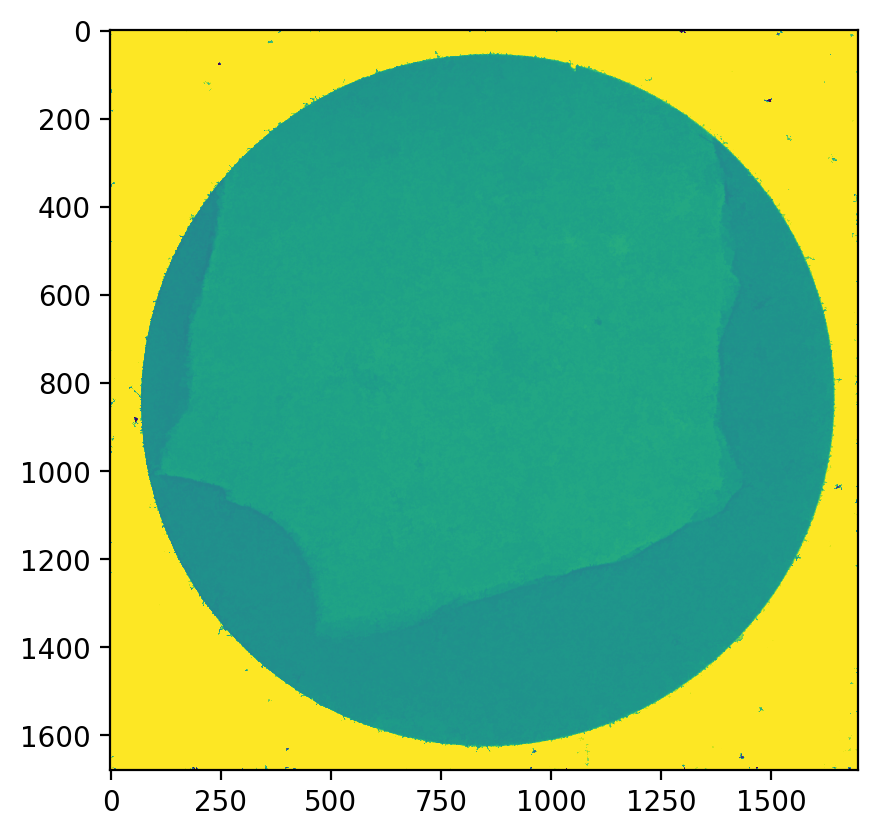

In [14]:
test_image  = rd.read_image(datapath_save + 'ABC_3/spotcleaned_00002.tif')

print(test_image)
print(np.max(test_image))
print(np.min(test_image))
plt.imshow(test_image,vmin=29000, vmax = 31000)
plt.show()


In [15]:
ROI =  [190, 140, 1888, 1818] # ROI in the format [x0,y0,x1,y1] ([200, 200, 848, 848])
N_pixels_x = ROI[2] - ROI[0]
N_pixels_y = ROI[3] - ROI[1]

N_projbatches = 3
N_proj = 3378
index_start = np.linspace(0,N_proj, num=N_projbatches, endpoint=False).astype(int)
incr = (N_proj ) / (N_projbatches )
index_end = (np.linspace( incr, N_proj, num=N_projbatches)-1).astype(int)
size_batch = N_proj//N_projbatches

N_slicebatches = 3
index_start_slice = np.linspace(0,N_pixels_y, num=N_slicebatches, endpoint=False).astype(int)
incr = (N_pixels_y ) / (N_slicebatches )
index_end_slice = (np.linspace( incr, N_pixels_y, num=N_slicebatches)-1).astype(int)
size_slice_batch = index_end_slice-index_start_slice+1


print(index_start_slice)
print(index_end_slice)

print(index_start)
print(index_end)

[   0  559 1118]
[ 558 1117 1677]
[   0 1126 2252]
[1125 2251 3377]


In [19]:
for i_slicebatch in range(N_slicebatches):
    size_slicebatch = index_end_slice[i_slicebatch]-index_start_slice[i_slicebatch]+1
    sino = np.empty((size_slicebatch,N_proj, N_pixels_x),dtype=np.uint16)
    for i_projbatch in range(N_projbatches):
        proj = io.read_images(datapath_save+'ABC_1/spotcleaned_{0:05d}.tif',index_start[i_projbatch]+1,index_end[i_projbatch]+1) # This takes a while
        sino[:,index_start[i_projbatch]:index_end[i_projbatch]+1,:] = np.transpose(proj[:,index_start_slice[i_slicebatch]:index_end_slice[i_slicebatch]+1,:], (1,0,2))
        del proj
        gc.collect()
    rd.save_TIFF(str(datapath_save + 'sinograms/ABC_1/sinocleaned_{0:05d}.tif'),sino, startIndex = index_start_slice[i_slicebatch]+1)
    del sino
    gc.collect()



  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/559 [00:00<?, ?it/s]

  0%|          | 0/1126 [00:00<?, ?it/s]

...

  0%|          | 0/559 [00:00<?, ?it/s]

  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/560 [00:00<?, ?it/s]

In [25]:
proj = io.read_images(datapath_save+'ABC_2/spotcleaned_{0:05d}.tif',1,1126).astype(np.uint16) # This takes a while
rd.save_TIFF(str(datapath_save + 'sinograms/ABC_2/sinocleaned_{0:05d}.tif'),np.transpose(proj,(1,0,2)), startIndex = 1)

  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/1678 [00:00<?, ?it/s]

In [26]:
proj = io.read_images(datapath_save+'ABC_3/spotcleaned_{0:05d}.tif',1,1126).astype(np.uint16) # This takes a while
rd.save_TIFF(str(datapath_save + 'sinograms/ABC_3/sinocleaned_{0:05d}.tif'),np.transpose(proj,(1,0,2)), startIndex = 1)

  0%|          | 0/1126 [00:00<?, ?it/s]

  0%|          | 0/1678 [00:00<?, ?it/s]